<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%202/02-markov-chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Markov Chains
**Week 2 | Mathematical Foundations for RL**

Markov chains are the mathematical backbone of MDPs. The **Markov property** states:

$$P(s_{t+1} | s_t, s_{t-1}, ..., s_0) = P(s_{t+1} | s_t)$$

The future depends only on the present — not the history. This is what makes RL tractable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. A Simple 3-State Markov Chain
States: Sunny (0), Cloudy (1), Rainy (2)

In [2]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
    [0.7, 0.2, 0.1],  # from Sunny
    [0.3, 0.4, 0.3],  # from Cloudy
    [0.2, 0.3, 0.5],  # from Rainy
])

state_names = ['Sunny', 'Cloudy', 'Rainy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]


## 2. Simulate a Trajectory

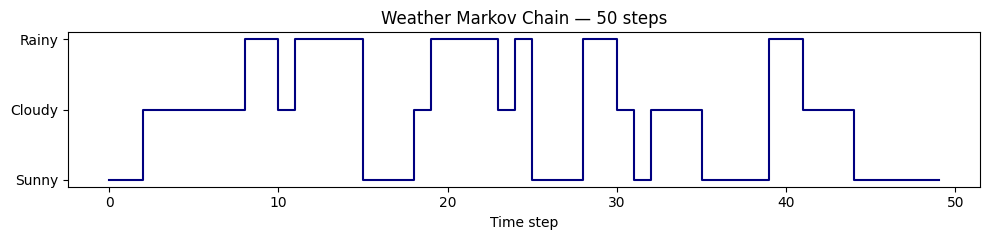

In [3]:
def simulate_markov(T, start_state, n_steps):
    trajectory = [start_state]
    state = start_state
    for _ in range(n_steps - 1):
        state = np.random.choice(len(T), p=T[state])
        trajectory.append(state)
    return np.array(trajectory)

traj = simulate_markov(T, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
colors = ['gold', 'skyblue', 'steelblue']
plt.step(range(len(traj)), traj, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain — 50 steps')
plt.tight_layout(); plt.show()

## 3. Stationary Distribution
After many steps, the chain settles into a **stationary distribution** π where π = π · T.

We can find it as the left eigenvector of T corresponding to eigenvalue 1.

In [4]:
# Analytical: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))  # eigenvalue closest to 1
stationary_analytical = np.real(eigenvectors[:, idx])
stationary_analytical /= stationary_analytical.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical, 4))

# Empirical: simulate 100,000 steps
long_traj = simulate_markov(T, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj) / len(long_traj)
print("Empirical  stationary distribution:", np.round(stationary_empirical, 4))

Analytical stationary distribution: [0.4565 0.2826 0.2609]
Empirical  stationary distribution: [0.4574 0.2815 0.2612]


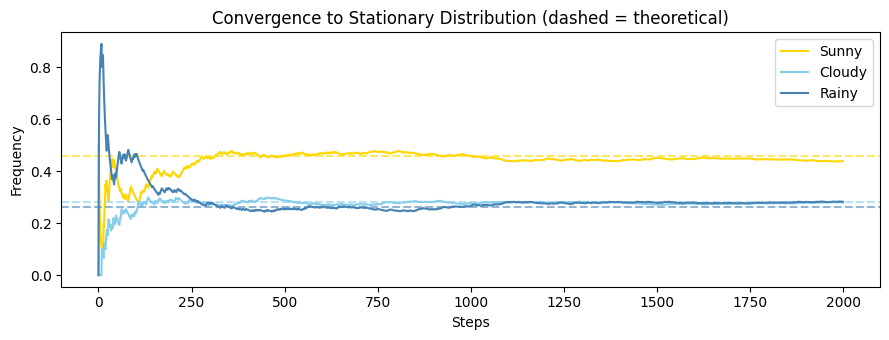

In [5]:
# Visualise convergence to stationary distribution
n_steps = 2000
state_freq = np.zeros((n_steps, 3))
traj_long = simulate_markov(T, start_state=0, n_steps=n_steps)
for t in range(1, n_steps):
    state_freq[t] = np.bincount(traj_long[:t+1], minlength=3) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['gold', 'skyblue', 'steelblue']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq[:, i], color=c, linewidth=1.5, label=name)
    ax.axhline(stationary_analytical[i], color=c, linestyle='--', alpha=0.6)
ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence to Stationary Distribution (dashed = theoretical)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Matrix Power — Another View
P(state at t=n | start state) = T^n · initial_distribution

In [6]:
init = np.array([1.0, 0.0, 0.0])  # start in Sunny
print(f"t=0:  {init}")
Tn = T.copy()
for t in [1, 5, 10, 50]:
    Tn_power = np.linalg.matrix_power(T, t)
    dist = init @ Tn_power
    print(f"t={t:<3}: {np.round(dist, 4)}")  # should converge to stationary

t=0:  [1. 0. 0.]
t=1  : [0.7 0.2 0.1]
t=5  : [0.4685 0.2794 0.2521]
t=10 : [0.4568 0.2825 0.2607]
t=50 : [0.4565 0.2826 0.2609]


## ✅ Exercises
1. Change the transition matrix so that once it rains, it always rains next (absorbing state). What happens to the stationary distribution?
2. Add a 4th state (Stormy) to the chain. Update T, make sure rows sum to 1, and re-run.
3. **Challenge**: prove to yourself that `π @ T == π` for the stationary distribution you computed above. Write the assertion.

In [7]:
# Exercise 1: Absorbing State (Once it rains, it stays raining)
T_absorbing = np.array([
    [0.7, 0.2, 0.1],  # from Sunny
    [0.3, 0.4, 0.3],  # from Cloudy
    [0.0, 0.0, 1.0],  # from Rainy (100% chance to stay Rainy)
])

# Check what happens to the distribution over time
init = np.array([1.0, 0.0, 0.0]) # Start Sunny
print("Absorbing state convergence:")
for t in [1, 5, 20, 50]:
    dist = init @ np.linalg.matrix_power(T_absorbing, t)
    print(f"t={t:<3}: {np.round(dist, 4)}")

# Conclusion: The stationary distribution becomes [0, 0, 1].
# Eventually, no matter the start state, the system gets "trapped" in the Rainy state.

Absorbing state convergence:
t=1  : [0.7 0.2 0.1]
t=5  : [0.3134 0.1428 0.5438]
t=20 : [0.0218 0.01   0.9682]
t=50 : [1.000e-04 0.000e+00 9.998e-01]


In [8]:
# Exercise 2: 4-State Markov Chain
state_names_4 = ['Sunny', 'Cloudy', 'Rainy', 'Stormy']

# T[i,j] = P(next=j | current=i)
T_4state = np.array([
    [0.6, 0.2, 0.1, 0.1],  # from Sunny
    [0.3, 0.4, 0.2, 0.1],  # from Cloudy
    [0.1, 0.3, 0.4, 0.2],  # from Rainy
    [0.0, 0.1, 0.3, 0.6],  # from Stormy
])

# Verify rows sum to 1
assert np.allclose(T_4state.sum(axis=1), 1), "Rows must sum to 1!"
print("New 4-State Transition Matrix:")
print(T_4state)

# Simulate a short trajectory
traj_4 = simulate_markov(T_4state, start_state=0, n_steps=20)
print(f"Trajectory over 20 steps: {traj_4}")

New 4-State Transition Matrix:
[[0.6 0.2 0.1 0.1]
 [0.3 0.4 0.2 0.1]
 [0.1 0.3 0.4 0.2]
 [0.  0.1 0.3 0.6]]
Trajectory over 20 steps: [0 0 0 0 0 3 1 1 3 1 1 0 0 0 0 1 0 1 0 0]


In [9]:
# Exercise 3: Prove π @ T == π
# We use np.allclose() instead of == because floating-point math can have microscopic differences (e.g., 0.9999999999999999 vs 1.0)

assert np.allclose(stationary_analytical @ T, stationary_analytical), "The property failed!"
print("Success! π @ T exactly equals π. The distribution is truly stationary.")

Success! π @ T exactly equals π. The distribution is truly stationary.
